In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_excel('/Users/tajveer/Desktop/IPL_team_followers.xlsx')

df['Total Followers'] = df['Total Followers'].str.replace('M', '').astype(float)

df['Brand Value (USD)'] = df['Brand Value (USD)']\
    .str.replace('$', '')\
    .str.replace(' million', '')\
    .astype(float)

df['Net Worth (₹ Crore)'] = df['Net Worth (₹ Crore)']\
    .str.replace('₹', '')\
    .str.replace(',', '')\
    .str.replace(' Cr', '')\
    .astype(float)
df

,Rankings,Teams,Total Followers,Brand Value (USD),Net Worth (₹ Crore),FY25 Revenue (Rs Cr),Total Matches Played,Matches won,win_percentage
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,0.556863
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,0.544803
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,0.488971
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,0.505618
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,0.456604
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,0.447761
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,0.474747
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,0.483193
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,0.596774
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,0.508475


In [ ]:

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error

features = df[['Total Followers', 'FY25 Revenue (Rs Cr)', 'Net Worth (₹ Crore)', 'win_percentage']]
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_values, columns=[
    'followers', 'revenue', 'net_worth', 'win_pct'
])
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_values, columns=[
    'followers', 'revenue', 'net_worth', 'win_pct'
])
w_followers = 0.4
w_revenue = 0.3
w_networth = 0.2
w_winpct = 0.1

df['brand_score'] = (
    w_followers * scaled_df['followers'] +
    w_revenue * scaled_df['revenue'] +
    w_networth * scaled_df['net_worth'] +
    w_winpct * scaled_df['win_pct']
)

min_val = df['Brand Value (USD)'].min()
max_val = df['Brand Value (USD)'].max()

df['Estimated_Brand_Value'] = (
    df['brand_score'] * (max_val - min_val) + min_val
)


mae = mean_absolute_error(df['Brand Value (USD)'], df['Estimated_Brand_Value'])
print("Mean Absolute Error:", mae)
df

Mean Absolute Error: 16.981945577704778


,Rankings,Teams,Total Followers,Brand Value (USD),Net Worth (₹ Crore),FY25 Revenue (Rs Cr),Total Matches Played,Matches won,win_percentage,brand_score,Estimated_Brand_Value
0,1,Chennai Super Kings,44.8,235.0,2033.0,674,255,142,0.556863,0.840710,245.584405
1,2,Mumbai Indians,41.4,242.0,2094.0,665,279,152,0.544803,0.797855,239.284721
2,3,Royal Challengers Bengaluru,38.4,269.0,2327.0,504,272,133,0.488971,0.596751,209.722355
3,4,Kolkata Knight Riders,30.8,222.0,1918.0,756,267,135,0.505618,0.730979,229.453952
4,5,Punjab Kings,17.0,141.0,1219.0,471,265,121,0.456604,0.146729,143.569150
5,6,Delhi Capitals,16.5,152.0,1314.0,603,268,120,0.447761,0.289539,164.562284
6,7,Sunrisers Hyderabad,15.5,154.0,1331.0,642,198,94,0.474747,0.341116,172.144117
7,8,Rajasthan Royals,14.1,146.0,1262.0,635,238,115,0.483193,0.314216,168.189802
8,9,Gujarat Titans,7.6,142.0,1227.0,559,62,37,0.596774,0.238273,157.026132
9,10,Lucknow Super Giants,5.8,122.0,1054.0,557,59,30,0.508475,0.131270,141.296690


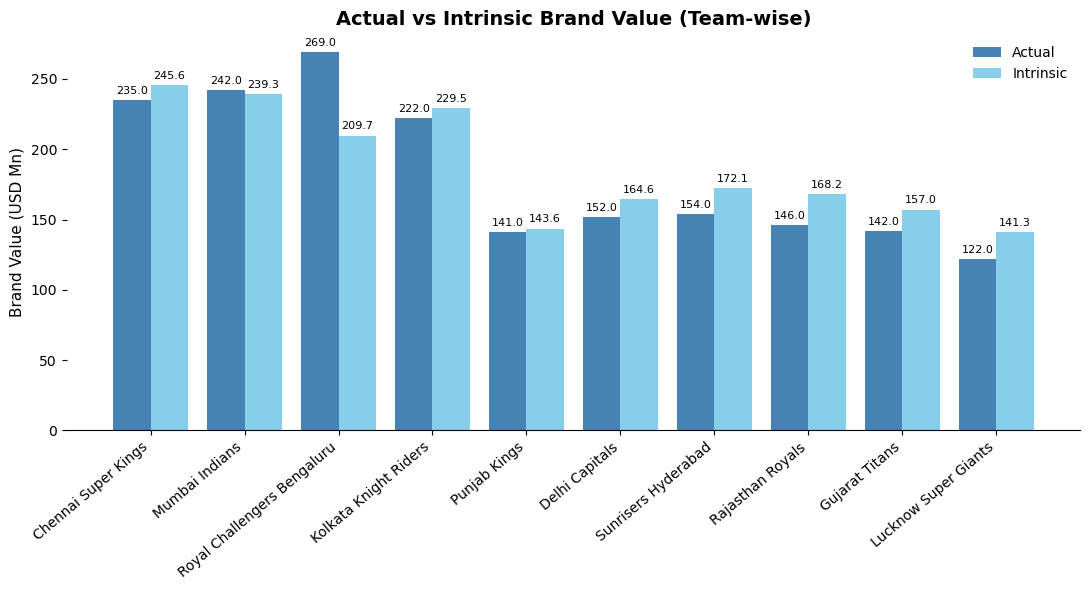

In [7]:


x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(11,6))

# Bars
ax.bar(x - 0.2, df['Brand Value (USD)'], width=0.4, label='Actual', color= 'steelblue') 
ax.bar(x + 0.2, df['Estimated_Brand_Value'], width=0.4, label='Intrinsic', color= 'skyblue')
ax.bar_label(ax.containers[0], fmt='%.1f', padding=3, fontsize=8)
ax.bar_label(ax.containers[1], fmt='%.1f', padding=3, fontsize=8)
# X-axis
ax.set_xticks(x)
ax.set_xticklabels(df['Teams'], rotation=40, ha='right')

# Titles & labels
ax.set_title("Actual vs Intrinsic Brand Value (Team-wise)", fontsize=14, weight='bold')
ax.set_ylabel("Brand Value (USD Mn)", fontsize=11)

# Legend
ax.legend(frameon=False)

# Clean styling
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

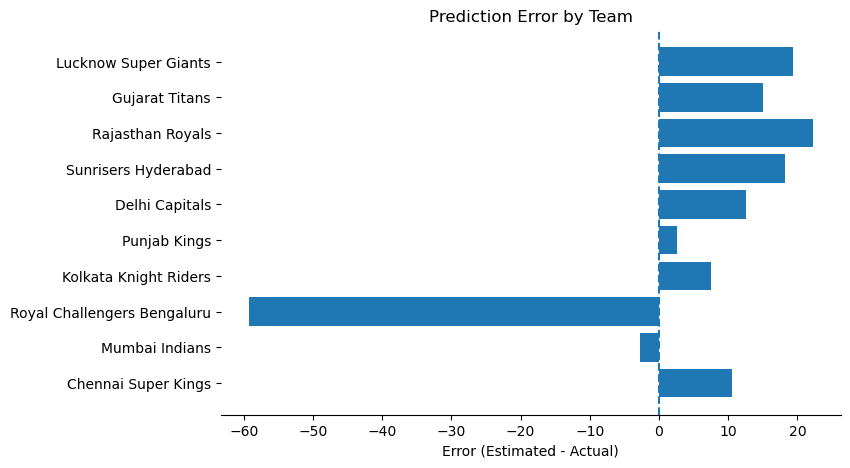

In [9]:
df['error'] = df['Estimated_Brand_Value'] - df['Brand Value (USD)']

plt.figure(figsize=(8,5))

plt.barh(df['Teams'], df['error'])

plt.xlabel("Error (Estimated - Actual)")
plt.title("Prediction Error by Team")

plt.axvline(0, linestyle='--')
plt.grid(False)
sns.despine(left=True, bottom=False)
plt.show()